In [1]:
# FP&A Forecasting Model — Driver-based + simple ML
# Author: Nicholas Hidalgo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error
np.random.seed(42)

In [3]:
months = pd.date_range(start="2023-01-01", periods=24, freq="M")

# Drivers
volume = np.round(np.random.normal(5200, 220, len(months))).astype(int)
price  = np.round(np.random.normal(19.5, 0.6, len(months)), 2)

revenue = volume * price
cost_pct = np.clip(np.random.normal(0.72, 0.03, len(months)), 0.6, 0.83)
cost  = (revenue * cost_pct).round(2)
margin = (revenue - cost).round(2)

df = pd.DataFrame({
    "Month": months,
    "Volume": volume,
    "Price": price,
    "Revenue": revenue,
    "Cost": cost,
    "Margin": margin
})

# Save for Tableau/Power BI and for versioning
df.to_csv("../data/synthetic_financials.csv", index=False)
df.head()

/var/folders/sl/tcws1nbx7l99931wvnscyxcm0000gn/T/ipykernel_78392/566440689.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range(start="2023-01-01", periods=24, freq="M")


,Month,Volume,Price,Revenue,Cost,Margin
0,2023-01-31,5192,19.68,102178.56,75993.36,26185.20
1,2023-02-28,5544,19.66,108995.04,75502.87,33492.17
2,2023-03-31,4624,19.50,90168.00,68715.57,21452.43
3,2023-04-30,5381,19.36,104176.16,70625.65,33550.51
4,2023-05-31,5219,18.65,97334.35,71794.37,25539.98


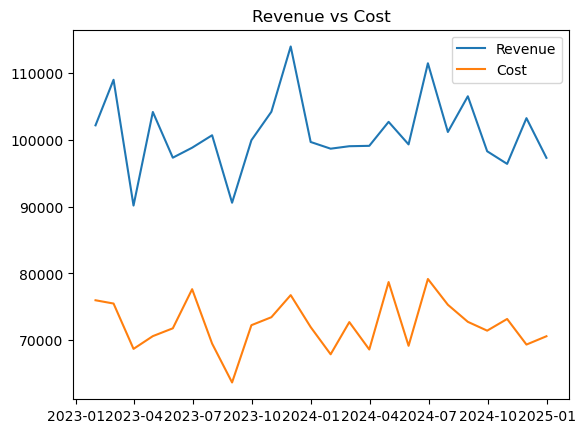

In [4]:
plt.figure()
plt.plot(df["Month"], df["Revenue"], label="Revenue")
plt.plot(df["Month"], df["Cost"], label="Cost")
plt.title("Revenue vs Cost")
plt.legend()
plt.show()

In [5]:
# Split train/test
train = df.iloc[:18].copy()
test  = df.iloc[18:].copy()

# Baseline: last actual revenue as forecast
baseline_forecast = [train["Revenue"].iloc[-1]] * len(test)

# Simple ML: linear regression on time + drivers
X_train = np.c_[np.arange(len(train)), train[["Volume","Price"]]]
y_train = train["Revenue"].values
X_test  = np.c_[np.arange(len(train), len(df)), test[["Volume","Price"]]]

lr = LinearRegression().fit(X_train, y_train)
ml_forecast = lr.predict(X_test)

test = test.assign(
    Baseline_Forecast = np.round(baseline_forecast, 2),
    ML_Forecast       = np.round(ml_forecast, 2)
)

mape_baseline = mean_absolute_percentage_error(test["Revenue"], test["Baseline_Forecast"])
mape_ml       = mean_absolute_percentage_error(test["Revenue"], test["ML_Forecast"])
mape_baseline, mape_ml

(0.11052956594527936, 0.0010028160963324274)

In [6]:
print(f"Baseline MAPE: {mape_baseline:.2%}")
print(f"ML MAPE:       {mape_ml:.2%}  (improvement: {(mape_baseline - mape_ml):.2%})")

# Simple scenarios by tweaking drivers (+/-)
scenarios = {
    "Base": {"vol_mult": 1.00, "price_mult": 1.00},
    "Optimistic": {"vol_mult": 1.03, "price_mult": 1.02},
    "Conservative": {"vol_mult": 0.97, "price_mult": 0.99},
}

scenario_df = []
for name, s in scenarios.items():
    v = (test["Volume"] * s["vol_mult"]).values.reshape(-1,1)
    p = (test["Price"]  * s["price_mult"]).values.reshape(-1,1)
    t = np.arange(len(train), len(df)).reshape(-1,1)
    Xs = np.c_[t, v, p]
    scenario_df.append(pd.DataFrame({
        "Month": test["Month"].values,
        "Scenario": name,
        "Revenue_Forecast": lr.predict(Xs)
    }))

scenario_df = pd.concat(scenario_df, ignore_index=True)
scenario_df.head()

Baseline MAPE: 11.05%
ML MAPE:       0.10%  (improvement: 10.95%)


,Month,Scenario,Revenue_Forecast
0,2024-07-31,Base,101155.920928
1,2024-08-31,Base,106492.477916
2,2024-09-30,Base,98279.354328
3,2024-10-31,Base,96231.179815
4,2024-11-30,Base,103394.371030


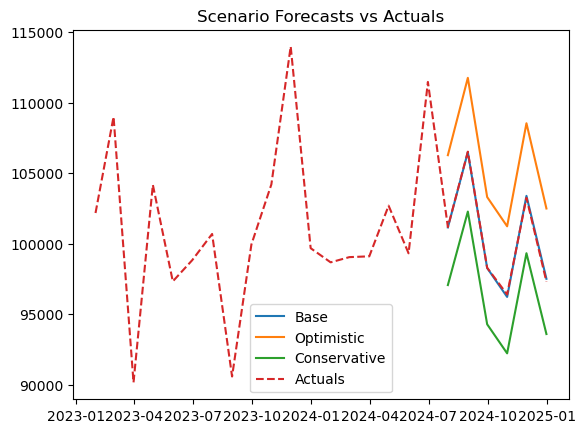

In [7]:
for s in scenario_df["Scenario"].unique():
    sub = scenario_df[scenario_df["Scenario"] == s]
    plt.plot(sub["Month"], sub["Revenue_Forecast"], label=s)

plt.plot(df["Month"], df["Revenue"], linestyle="--", label="Actuals")
plt.title("Scenario Forecasts vs Actuals")
plt.legend()
plt.show()